<div style="text-align: center; font-size: 30px;">
Prácticas de Estadística<br/>
</div>
<div style="text-align: center; font-size: 30px;">
Papel Probabilístico
</div>
<div style="text-align: center; font-size: 16px; font-style: italic">
Material elaborado por M. Dolores Frías, Jesús Fernández y Carmen M. Sordo profesores del Departamento de Matemática Aplicada y Ciencias de la Computación de la Universidad de Cantabria.
</div>

# Objetivos

Los métodos gráficos han sido tradicionalmente utilizados en ingeniería
debido a su sencillez y utilidad para analizar datos y comprender su
estructura. Con la popularización de los ordenadores como herramienta habitual
de trabajo, la representación gráfica ha pasado de realizarse manualmente a ser
hecha en el ordenador. Uno de los métodos gráficos tradicionales que puede
ser fácilmente implementado en R es el basado en el concepto de papel
probabilístico.

La idea básica del papel probabilístico, de una familia
biparamétrica de funciones de distribución,  es modificar las escalas
del dibujo de la variable aleatoria y de la probabilidad acumulada, de tal
forma que dicha familia se convierta en una familia de rectas. De esta manera,
cuando se representa la función de distribución en dicho papel, el
aspecto de la gráfica (rectilinea o no) sirve para decidir si los datos
proceden de esa familia de distribuciones o no. Además, de la
representación pueden obtenerse también los parámetros de la
distribución concreta que mejor se ajusta.


# Función de distribución empírica (ECDF)

Si tomamos una muestra de una población cuya función de distribución
desconocemos, podemos construir una *función de distribución muestral*
conocida como **función de distribución empírica** (ECDF, del inglés *Empirical Cumulative Distribution Function*). Esta función nos dará la probabilidad de obtener un valor menor o igual que uno dado a la vista de la
muestra que hemos obtenido. 

Para construirla ordenamos los valores $x_i$ que ha tomado la variable en nuestra muestra de tamaño $n$. Al elemento que ocupa el lugar i-ésimo una vez ordenada la muestra de menor a mayor se le conoce como **estadístico de
orden** $i$, y lo denotaremos por $x_{i:n}$. 

La función de distribución empírica asigna a cada valor obtenido en la muestra una probabilidad acumulada $i/n$:

$S_n(x_{i:n})= \frac{i}{n}$

En realidad, esta función está definida en toda la recta real y tiene forma escalonada. En R, se puede obtener mediante la función `ecdf`:

[1] 0.82

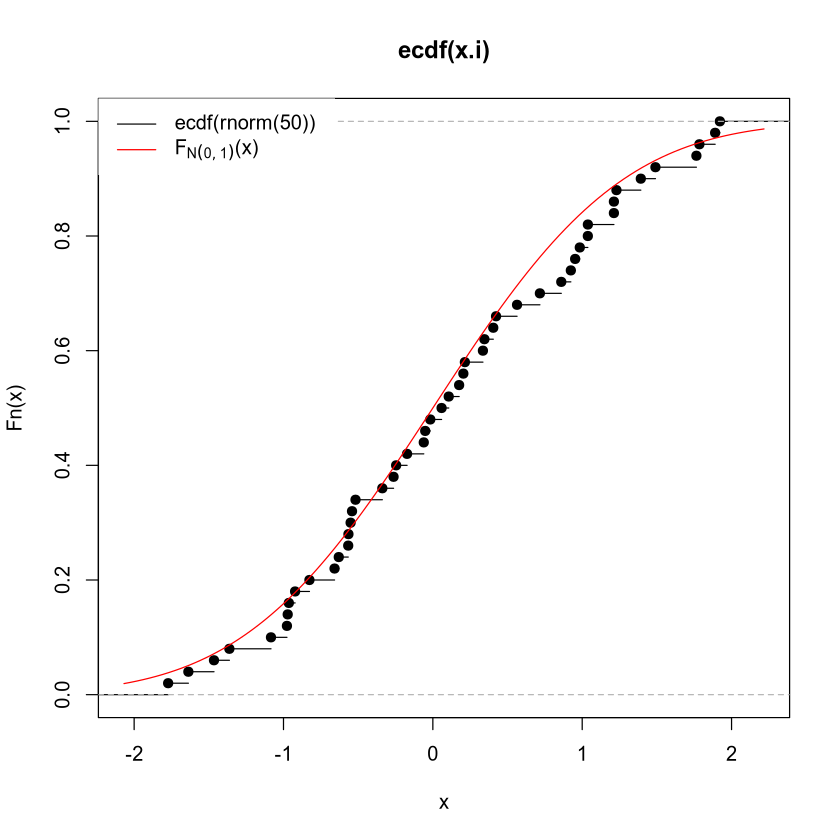

In [2]:
x.i <- rnorm(50)       # Tomamos muestra de tamaño 50 de N(0,1)
Sn <- ecdf(x.i)        # Construimos su ECDF
Sn(1.2)                # Podemos usarla como una función...
plot(Sn)               # ... plot la interpreta de forma especial
curve(pnorm(x), col="red", add=T)  # Podemos compararla con la dist. de la poblacion de origen
legend("topleft", legend=c("ecdf(rnorm(50))", expression("F"[N(0,1)]*"(x)")),
       col=c("black","red"), lty=1, box.lty=0)

Esta función de distribución empírica es la que queremos representar en papel probabilístico, es decir, en un gráfico con nuevas escalas en los ejes, de tal forma que sus puntos queden formando una línea recta en
lugar de la curva que hemos obtenido con el código anterior. 
 
Sin embargo, en el caso de muchas familias de distribuciones, al valor $1$ (que alcanza
$S_n(x_{n:n})$), cuando se le aplica la transformación de escala se
transforman en $\infty $. Por ello, es imposible dibujarlo. Una solución a este
problema consiste en usar otras **fórmulas de punteo**, diferentes de
$i/n$ para asignar la probabilidad acumulada hasta cada dato de la muestra. La
siguiente tabla resume diferentes fórmulas de punteo propuestas por diferentes
autores:

<div><img alt="Plotting positions" src="./figuras/tabla_punteo_en.png" width="250"/></div>

En lo que sigue utilizaremos la fórmula de Hazen, aunque en R podemos utilizar cualquier otra sin mayor dificultad. 

Para el desarrollo de esta práctica hemos programado una serie de funciones contenidas en el fichero *papeles.R* que entre otras incluye también funciones para calcular estos punteos de la siguiente manera:

In [3]:
source("functions/papeles.R")    # Cargamos el fichero con funciones de esta practica 
punteo.hazen(50)       # Nos devuelve las probabilidades asignadas por el punteo Hazen

[1] 0.01 0.03 0.05 0.07 0.09 0.11 0.13 0.15 0.17 0.19 0.21 0.23 0.25 0.27 0.29
[16] 0.31 0.33 0.35 0.37 0.39 0.41 0.43 0.45 0.47 0.49 0.51 0.53 0.55 0.57 0.59
[31] 0.61 0.63 0.65 0.67 0.69 0.71 0.73 0.75 0.77 0.79 0.81 0.83 0.85 0.87 0.89
[46] 0.91 0.93 0.95 0.97 0.99

Recordar que la orden `source("papeles.R")` solo se debe ejecutar una vez al principio de esta práctica para tener cargadas todas las funciones que necesitamos. Además para que esa orden funcione debemos haber establecido el directorio de trabajo que contiene al fichero con el comando `setwd()`.

In [ ]:
punteo.gringorten(50) # Punteo Gringorten

R dispone también de una función genérica `ppoints(n,a)` que implementa la fórmula $p_{i:n}=\frac{i-a}{n+(1-2a)}$ que permite calcular estos y otros punteos dependiendo del valor de a. Por ejemplo, los dos casos de arriba se pueden obtener como `ppoints(50,0.5)` (Hazen) y `ppoints(50,0.44)` (Gringorten).

# Fundamentos del papel probabilístico

El papel probabilístico es, simplemente, un papel en el que se han cambiado las escalas de tal manera que las funciones de distribución de una cierta familia, cuando se dibujan en él, se convierten en una familia de líneas
rectas.

Sea $F_X(x;\theta_1,\theta_2)$ una familia biparamétrica de funciones de distribución, donde $\theta_1$ y $\theta_2$ son los parámetros. Se busca una transformación 
\begin{equation}
\xi =g(x)\quad;\quad \eta =h(y)\quad \quad \quad (1)
\end{equation}
tal que la familia de curvas
\begin{equation}
y=F_X(x;\theta_1,\theta_2)\quad \quad \quad (2)
\end{equation}
cuando se transforma por (1) se convierten en una familia de líneas rectas, es decir: 
\begin{equation}
h(y)=h[F_X(x;\theta_1,\theta_2)]=ag(x)+b\quad \quad \Leftrightarrow \quad \quad \eta
=a\xi +b  \quad \quad \quad (3)
\end{equation}
donde la variable $\eta $ se llama variable reducida y $a=a(\theta_1,\theta_2)$ y $b=b(\theta_1,\theta_2)$ son, respectivamente, la pendiente y la ordenada en el origen de la recta en la que se transforma $F_X(x;\theta_1,\theta_2)$.

Por tanto, para que exista un papel probabilístico asociado a una cierta
familia de funciones de distribución $F_X(x;\theta_1,\theta_2)$ se necesita que
\begin{equation}
F_X(x;\theta_1,\theta_2)=h^{-1}[ag(x)+b]\quad \quad \quad (4)
\end{equation}

Dada una familia de distribuciones conocida, tendremos que buscar la forma de
las transformaciones $h$ y $g$ que hacen posible el papel probabilístico para esa familia. 

En esta práctica refrescaremos una de las transformaciones vistas en clase que hace posible el papel normal y analizaremos en detalle la transformación necesaria del papel exponencial. Además de estos dos papeles, también utilizaremos el resto de papeles probabilísticos cuyas transformaciones hemos visto en detalle clase.

# Papel Normal

Si $F_X(x;\mu , \sigma )$ es la función de distribución de
una variable normal, sabemos que puede ser escrita como:
\begin{equation}
F_X(x;\mu , \sigma )=\Phi \left({{x-\mu } \over \sigma }\right)\quad \quad \quad (5)  
\end{equation}
donde $\mu $ y $\sigma $ son la media y la desviación típica, respectivamente, y $\Phi (x)$ es la función de distribución de la variable normal estándar $F_{N(0,1)}(x)$.

Entonces, según (1) y (3), la ecuación (5) es:
\begin{equation}
\xi =g(x)=x\quad;\quad\eta =h(y)=\Phi ^{-1}(y)\quad;\quad a={1 \over \sigma
}\quad;\quad b=-\frac{\mu}{\sigma}\quad \quad \quad (6) 
\end{equation}
y la familia de líneas rectas es
\begin{equation}
\eta =a\xi +b={{\xi -\mu } \over \sigma } \quad \quad \quad (7) 
\end{equation}

Si los puntos $\left( g(x_{i:n}), h\!\left(\frac{i-0.5}{n}\right) \right) = \left(x_{i:n}, \Phi^{-1}\!\left(\frac{i-0.5}{n}\right) \right)$ se alinean formando una recta, se acepta la hipótesis de normalidad y la estimación de los
parámetros $\mu $ y $\sigma $ puede hacerse tras ajustar una recta a los mismos. Notar que haciendo $\eta =0$ y $\eta =1$ en (7) se obtiene:
\begin{equation} \begin{array}{l}\eta =0\quad\Rightarrow \quad 0={{\xi -\mu }
\over \sigma }\quad\Rightarrow \quad\xi_{\eta =0} =\mu \\
  \eta =1\quad \Rightarrow \quad 1={{\xi -\mu } \over \sigma }\quad\Rightarrow\quad \xi_{\eta =1} =\mu +\sigma
\end{array} \end{equation}

La siguiente figura muestra un papel probabilístico normal, donde el eje de las ordenadas ha sido transformado por $\eta =\Phi ^{-1}(y)$ y el eje de abscisas no ha sufrido transformación alguna. En este papel se representan directamente los puntos de la función de distribución empírica: $\left( x_{i:n}, \frac{i-0.5}{n}\right)$.

<div><img alt="papel_normal" src="./figuras/papel_normal.png" width="500"/></div>

*Normal probability paper representing data from a sample of size 50 taken from a standardized Normal distribution.* 

## Papel Normal en R

En R se pueden dibujar fácilmente las transformaciones de los datos necesarias
para representar un conjunto de datos en papel normal. Para ello, basta utilizar la función `qnorm` como $h(y)$ para transformar las probabilidades empíricas. Sin embargo, en las instrucciones del fichero *papeles.R* se
define una función `papel.normal` que facilita la representación. Para utilizarla basta ejecutar el siguiente código:

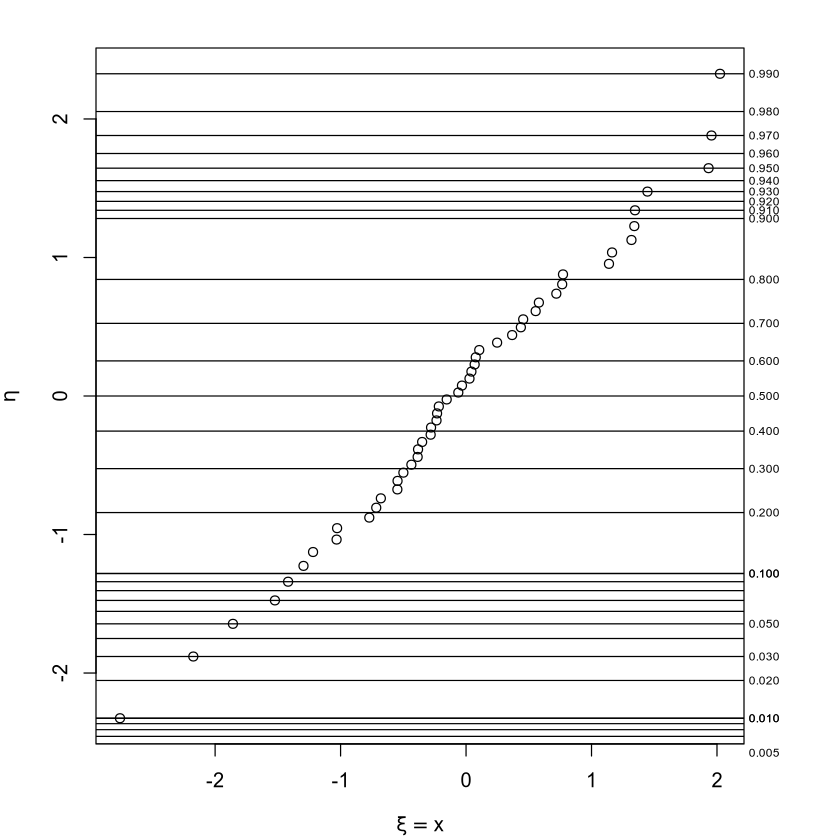

In [4]:
load("data/normal.rda")  # carga la variable data
papel.normal(data)

Como vemos los puntos se ajustan bastante bien a lo largo de una recta imaginaria, luego podemos determinar que la muestra proviene de una distribución Normal. En base a este resultado, podeis determinar la recta que mejor se ajusta a los datos mediante mínimos cuadrados utilizando el argumento `show.fit` que, como vemos, además nos añade en el gráfico el valor de $\xi_{\eta=0}=\mu=-0.04$ y $\xi_{\eta=1}=\mu+\sigma=1.01$. A partir de estos dos datos podemos obtener el valor de los parámetros de la distribución Normal de partica que serán: $\mu=-0.04$ y $\sigma=1.05$.

$mean
[1] -0.0444501

$sd
[1] 1.054324

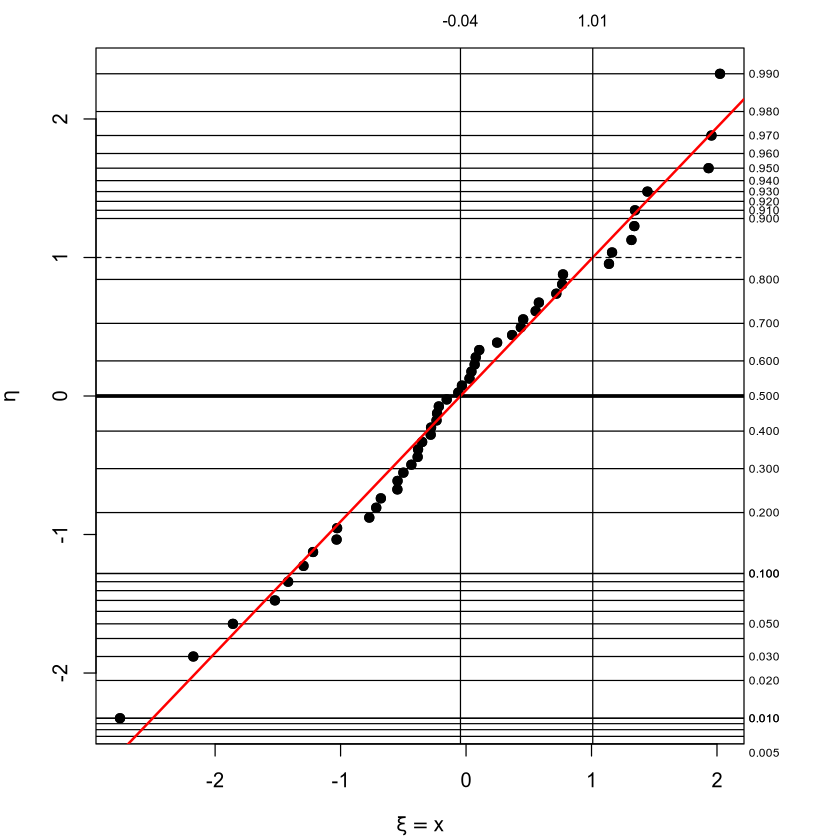

In [5]:
papel.normal(data, show.fit=TRUE)

Notar que la salida de esa función devuelve los valores de $\mu$ *(mean)* y $\sigma$ *(sd)* anteriores. Estos dos valores se pueden guardar en una variable para así poder usarlos posteriormente para cualquier otro cálculo. Por ejemplo para calcular una probabilidad como en el siguiente ejemplo en el que se calcula P(X<=2)=0.97:

[1] 0.973756

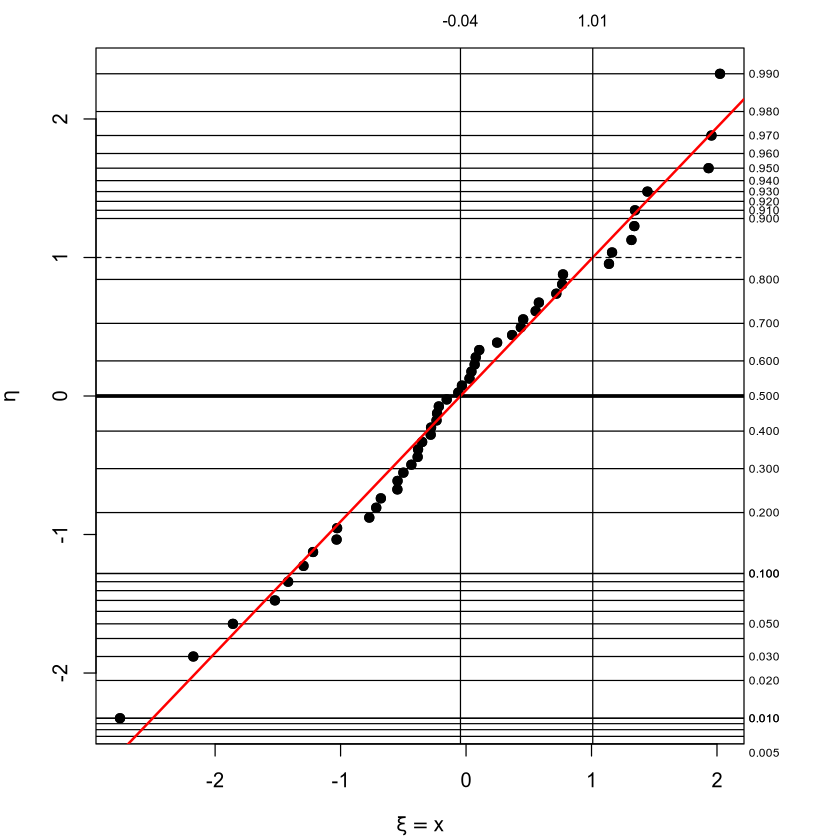

In [6]:
papelnorm_out <- papel.normal(data, show.fit=TRUE)
# P(X<=2) 
pnorm(2, papelnorm_out$mean, papelnorm_out$sd)

A menudo, los datos más extremos de una muestra no se ajustan bien a una recta. Esto se debe a que las regiones con poca probabilidad de ocurrencia (las colas de la distribución) necesitan de tamaños de muestra muy grandes para disponer de un número de datos suficiente como para representarlas adecuadamente. Es común que falten valores en rangos que tenían una pequeña probabilidad de ocurrir y que aparezcan valores en otros rangos más improbables. Por esta razón, a veces, es preferible descartar los datos más extremos de la muestra y ajustar la recta únicamente a los valores que realmente se alinean. La función `papel.normal` admite el argumento `trim=N`, para eliminar `N` puntos de cada cola antes de hacer el ajuste lineal. 

Pruébalo con los datos anteriores y observa el efecto sobre la recta y el cambio en el valor de los parámetros resultantes para la distribución Normal:

$mean
[1] -0.03058498

$sd
[1] 1.019299

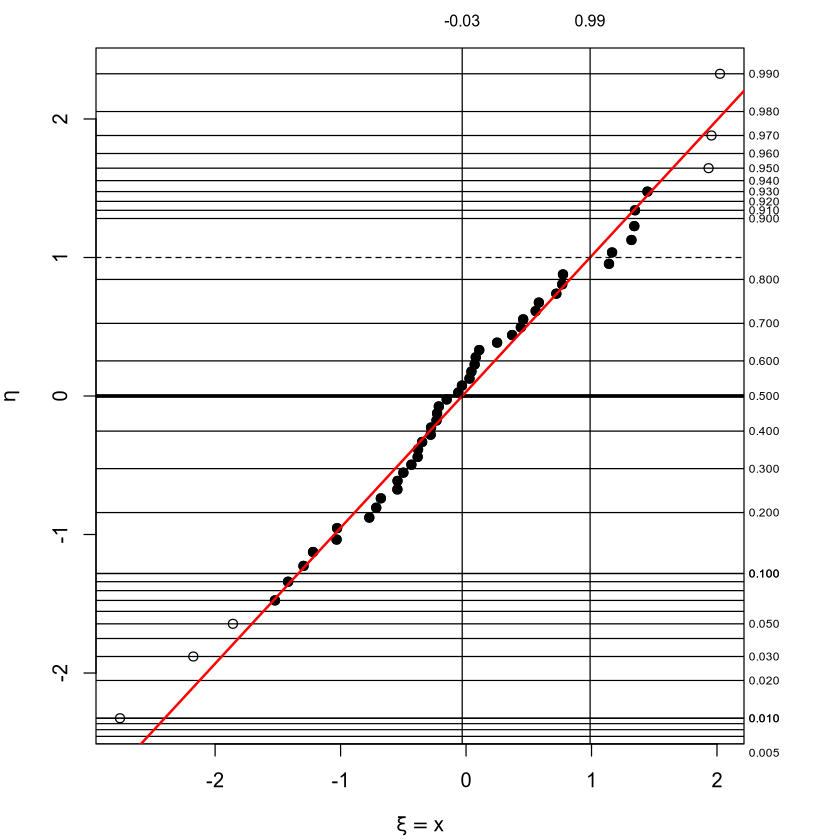

In [7]:
papel.normal(data, show.fit=TRUE, trim=3)

<div class="alert alert-block alert-info">
<strong>PRACTICA TÚ MISMO</strong>

- El fichero *resistencias.rda* contiene datos de resistencia a la compresión (en Kg/cm$^2$) de 40 probetas de hormigón.
  1. Comprobar si se puede aceptar la hipótesis de que las resistencias se distribuyen de forma normal.
  2. Obtener la resistencia media y la desviación típica a partir del modelo normal ajustado.
  3. Si se define la resistencia característica como aquella que es superada por el 95% de las muestras y damos por bueno el ajuste anterior ¿Cuál es la resistencia característica de este hormigón? Observa el gráfico obtenido antes e identifica ese valor en el propio gráfico.

</n>

- El fichero *datos_papeles.rda* contiene 4 muestras de 30 datos cada una. Al cargar el fichero, están disponibles en las variables: data1, data2, data3 y data4. Representar las muestras sobre papel normal y en caso de que sea aceptable este modelo, obtener los parámetros de la distribución.

</div>

# Papel exponencial

El papel probabilístico exponencial transforma la función de distribución exponencial en una línea recta. Vamos a generalizar la variable aleatoria exponencial respecto a la que hemos visto en teoría, añadiéndole un parámetro de localización $x_0$, es decir:

$F_{Ex(\alpha,x_0)}(x) = 1- e^{-\alpha(x-x_0)} \qquad \forall x \ge x_0$

Esta distribución se conoce como distribución exponencial desplazada. Haciendo $x_0=0$ se recupera la distribución exponencial ordinaria. 

Si hacemos las transformaciones

$\eta = h(y) = -\ln(1-y) \qquad \xi=g(x) = x$

podemos escribir la exponencial desplazada como

$y = 1- e^{-\alpha(x-x_0)}
\;\Rightarrow\; \eta = h(y) = -\ln(1-y) = \alpha(x-x_0) = \alpha(\xi -x_0)$

Es decir

$\eta = a\xi +b$

con $a=\alpha$ y $b=-\alpha x_0$.

De nuevo, los cortes con las rectas $\eta=0$ y $\eta=1$, nos permiten obtener los parámetros de la distribución:
\begin{eqnarray}
\eta = 0 & \;\Rightarrow\; & 0 = \alpha(\xi -x_0) \;\Rightarrow\; \xi_{\eta=0} = x_0 \\
\eta = 1 & \;\Rightarrow\; & 1 = \alpha(\xi -x_0) \;\Rightarrow\; \xi_{\eta=1} = x_0+\alpha^{-1}
\end{eqnarray}


## Papel exponencial en R

El fichero *papeles.R* incluye la función `papel.exponential` para dibujar fácilmente las transformaciones de los datos necesarias para representar un conjunto de datos en papel exponencial. Para ello, basta hacer:

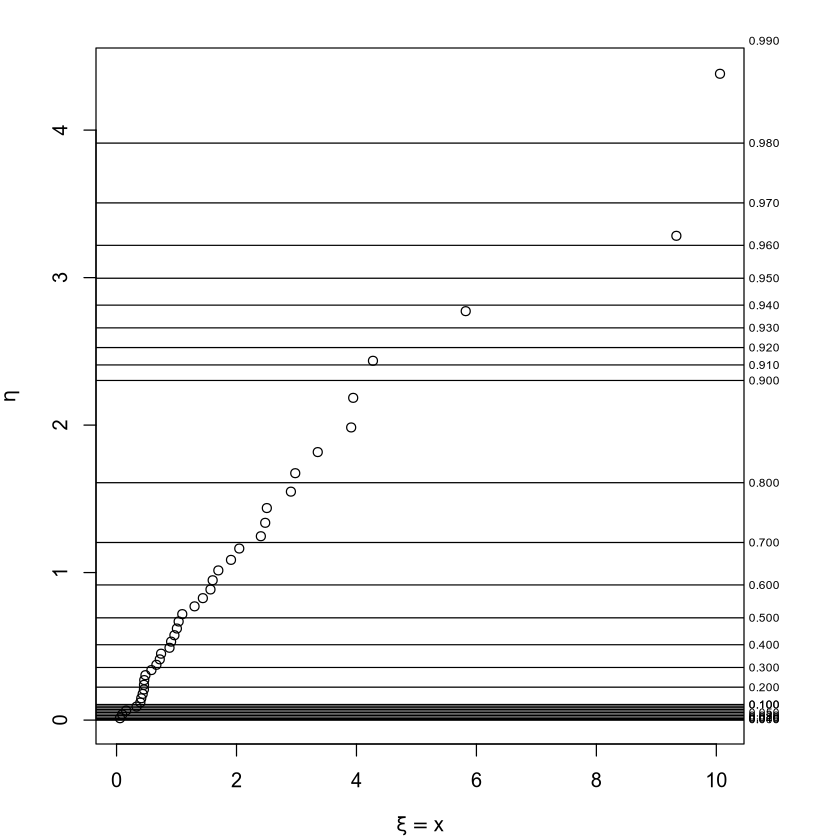

In [8]:
data <- rexp(40, 0.5)  # 40 datos aleatorios de una dist. Ex(0.5)
papel.exponencial(data)

La muestra de 40 datos se ajusta bastante bien a una línea recta, por lo que confirmamos que proviene de una distribución exponencial, algo que ya sabíamos puesto que los datos fueron generados con la función `rexp()`. Por todo ello podemos ahora ajustar la recta de regresión lineal a esa nube de puntos. Al igual que en el caso de la normal, la función `papel.exponencial` admite los argumentos `show.fit` y `trim`. Además tiene un argumento `allow.shift=FALSE`, que ajusta la versión no desplazada de la distribución exponencial (es decir, obliga a tener $x_0=0$).

Realiza el ajuste y obtén los parámetros de la distribución exponencial. 

<div class="alert alert-block alert-info">
<strong>PRACTICA TÚ MISMO</strong>

Comprobar si alguna de las muestras del fichero *datos_papeles.rda* responde a una distribución exponencial y, en tal caso, obtener sus parámetros.
</div>

# Papel extremal

En esta parte de la práctica trataremos el uso del papel probabilístico
para el caso de extremos. Nos centraremos por tanto en analizar las colas de la
distribución (derecha o izquierda según interese) ya que esta es la única
parte de la función de distribución que gobierna el comportamiento de los
extremos, ya sean máximos o mínimos.

Como ejemplo vamos a considerar la distribuciones Normal y Esponencial, para
ilustrar el papel de las colas en el comportamiento de los extremos. Con este
fin vamos a utilizar algunas de las funciones contenidas en el fichero
*papeles.R* para representar muestras de estas dos distribuciones
comunes en el papel probabilístico de Gumbel de máximos y de mínimos. Así podremoas analizar en cada caso el dominio de atracción de los extremos.

Usaremos el fichero *distribuciones.rda* que contiene datos provenientes
de una distribución $N(\mu=6, \sigma=2)$ y $Exp(\alpha=0.2)$.

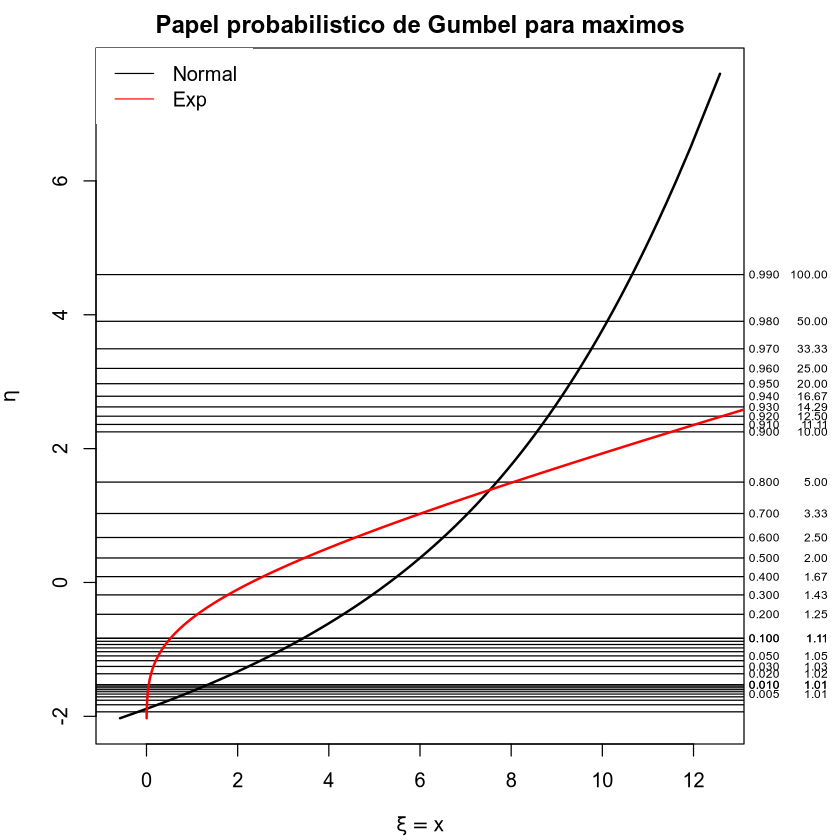

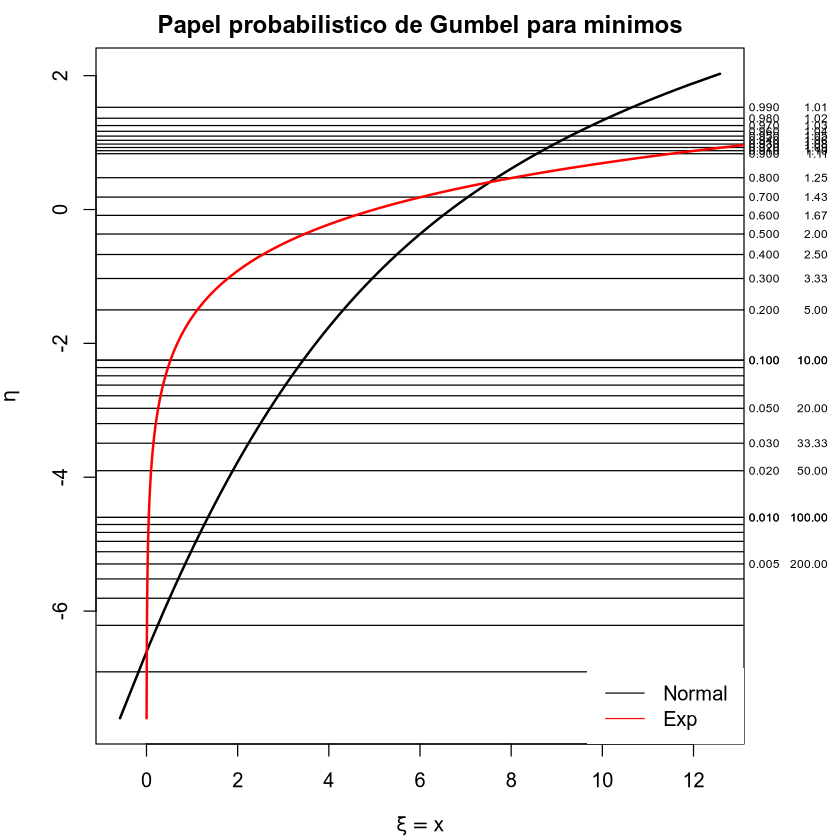

In [9]:
# Carga de datos 
load("data/distribuciones.rda")
attach(distribuciones)
# Papel probabilistico de Gumbel para maximos
papel.maximal(normal, x.transform="gumbel", type="l", lwd=2)
title("Papel probabilistico de Gumbel para maximos")
papel.maximal.lines(exp, col="red", lwd=2)
legend("topleft", legend=c("Normal", "Exp"),
       col=c("black","red"), lty=1, box.lty=0, bg="white")
# Papel probabilistico de Gumbel para minimos
papel.minimal(normal, x.transform="gumbel", type="l", lwd=2)
title("Papel probabilistico de Gumbel para minimos")
papel.minimal.lines(exp, col="red", lwd=2)
legend("bottomright", legend=c("Normal", "Exp"),
       col=c("black","red"), lty=1, box.lty=0, bg="white")


En este caso hemos usado las funciones `papel.maximal.lines`
y `papel.minimal.lines` del fichero `papeles.R` que nos permiten
añadir la representación de otra muestra al gráfico del papel
probabilístico maximal o mininal ya creado. Además, hemos utilizado el
argumento `type="l"` que ya conoceis puesto que lo admiten la mayoría de
las funciones para dibujar de R usadas en prácticas anteriores, con objeto
de representar los datos unidos con una línea en lugar de marcar los valores
con puntos.

La representación de estas dos distribuciones en el papel probabilístico de
Gumbel para máximos, muestra una linealidad de la cola derecha en ambas distribuciones lo que confirma que tanto la distribución Normal como la Exponencial pertenecen al dominio de atracción de Gumbel para
máximos.

Cuando representamos esas dos distribuciones en el papel probabilístico de Gumbel para mínimos, se
aprecia la linealidad de la cola izquierda de la distribución Normal, indicando
así un dominio de atracción para mínimos tipo Gumbel. En el caso de la
Exponencial se observa una pendiente vertical al aproximarse a su límite
inferior. Esto sugiere un dominio de atracción para mínimos tipo Weibull. 

El análisis de ambas distribuciones confirma los dominios de atracción de los
extremos que ya habíamos obtenido en clase para estas dos distribuciones
comunes.

<div class="alert alert-block alert-info">
<strong>PRACTICA TÚ MISMO</strong>

- El fichero *T1007_llamadas_telefonicas.txt* contiene los tiempos en segundos entre $36$
llamadas consecutivas realizadas en una central telefónica automática (Castillo y Pruneda, 2001)
  1. Cargar estos datos en R.
  2. Representar estos datos en papel probabilístico exponencial ¿Puede decirse que la ocurrencia de llamadas a esta centralita sigue un proceso de Poisson homogéneo?
  3. Obtener la tasa de ocurrencia de llamadas en la centralita.
  4. Determinar la probabilidad de que haya que esperar como mucho 5 milisegundos para recibir una llamada.
  5. Estimar el dominio de atracción para mínimos y para máximos.
  
</div>